In [16]:
import xarray as xr 
import numpy as np 
from pathlib import Path
from dask.distributed import Client
import sys, os

import pandas as pd

In [17]:
client = Client(
    n_workers=8,
    threads_per_worker=1
)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42427 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/42427/status,
Dashboard: /proxy/42427/status,Workers: 8
Total threads: 8,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42137,Workers: 0
Dashboard: /proxy/42427/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33845,Total threads: 1
Dashboard: /proxy/45833/status,Memory: 2.25 GiB
Nanny: tcp://127.0.0.1:37159,


In [28]:
cf_threshold = 10

In [80]:
def open_files(root_path, preprocess=None):
    files = [f for f in root_path.glob('*.nc')]

    return xr.open_mfdataset(
        files,
        preprocess = preprocess,
        concat_dim='year',
        combine='nested',
        parallel=True,
        chunks='auto'
    )

In [81]:
folder_out = Path("/home/563/fm6730/localrepo/GC26-combined-solar-wind/data/processed/hour_capacity_factor_lower_than/merged_out/")

In [82]:
him_path = Path(f"/home/563/fm6730/localrepo/GC26-combined-solar-wind/data/processed/hour_capacity_factor_lower_than/")
him_files = [f for f in him_path.rglob(f'*_{cf_threshold}pc_*.nc')]

def preprocess(ds):
    return ds

him_ds = open_files(him_path, preprocess=preprocess)


In [83]:
him_ds

<xarray.Dataset> Size: 34MB
Dimensions:     (year: 84, lat: 141, lon: 181)
Coordinates:
  * lon         (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0
  * lat         (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * year        (year) int64 672B 2002 2014 1966 2008 ... 2001 2009 1971 2011
Data variables:
    count_hour  (year, lat, lon) int64 17MB dask.array<chunksize=(1, 141, 181), meta=np.ndarray>
    percentage  (year, lat, lon) float64 17MB dask.array<chunksize=(1, 141, 181), meta=np.ndarray>

In [68]:
da = him_ds['count_hour']

In [69]:
da_sel = da.sel(year=2000)

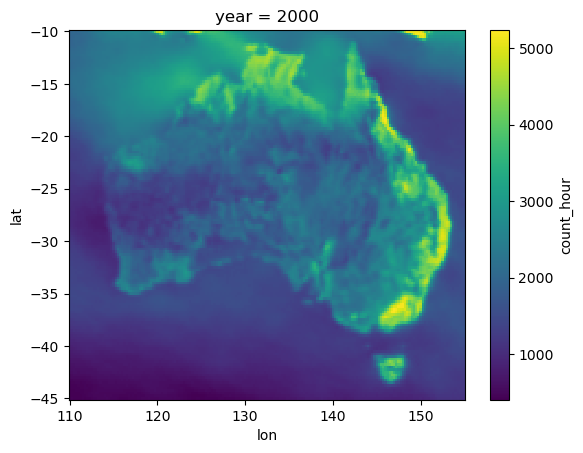

In [70]:
da_sel.plot()

In [71]:
da_summed = da.sum(dim='year')

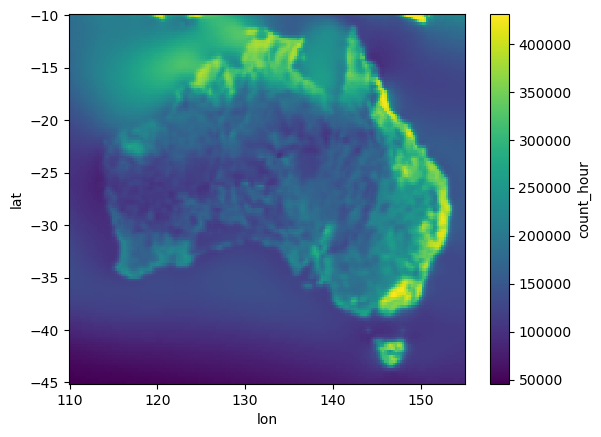

In [72]:
da_summed.plot()

In [73]:
n_hours = len(pd.date_range(start='1940-01-01', end='2023-12-31 23:00', freq='h'))

In [74]:
print(n_hours)

736344


In [75]:
6000*84/n_hours*100

68.44626967830253

In [76]:
da_percentage = da_summed/n_hours * 100.

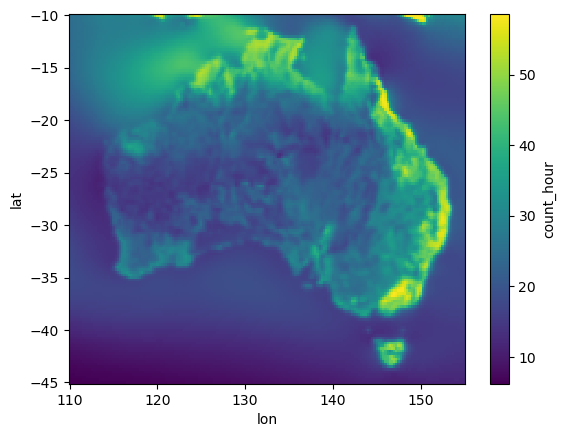

In [77]:
da_percentage.plot()

In [78]:
ds_out = xr.Dataset({
    'count_hour': da_summed,
    'percentage': da_percentage,
})

In [79]:
ds_out.to_netcdf(f"{folder_out}/hour_capacity_factor_lower_than_{cf_threshold}pc_1940-2023.nc")